# J-map analysis on running-ratio AIA maps — 18 January 2026 eruption

Trace EUV intensity along radial slits (and great arcs) rooted at the eruption
source region of the 18 January 2026 event (AR 4341, X1.9 flare, onset 17:27 UT,
GOES peak 18:09 UT; eruption centre near (-60, -260) arcsec). Build
distance--time (J-) plots per slit, manually trace the moving front (repeated,
for an uncertainty estimate), and derive its kinematics
(distance, speed, acceleration).

AIA 211/193/171 frames are read **from disk on the remote server** (no download)
at the processing level set by `AIA_LEVEL` (1 or 1.5). One running-ratio RGB
sequence is built and can be exported as PNG stills; it is then traced two ways
(`TRACE_METHODS`): **radial slits** in the plane of sky and **great arcs** on the
solar surface (SunPy), compared at the end.

**Workflow**
1. Edit the single **Configuration** block below; nothing else needs touching.
2. Run the function-definition cells once.
3. Run the *build sequence* cell to produce the running-ratio RGB time series and slit traces.
3b. (optional) Export the RGB sequence as PNG stills to `RGB_SEQ_DIR` to show the eruption evolution.
4. For each slit set `ACTIVE_SLIT_ID`, then trace the front with whichever method
   `TRACE_MODE` selects: **manual** (left-click points, right-click to store each of
   `N_REPEATS` repeats) or **Bezier** (drag the start/end/anchor sliders onto the front,
   then commit a jittered ensemble). Both write the same store, so steps 5-6 are identical.
5. Aggregate, save, and plot.
6. Repeat 4--5 for the great arcs (section at the bottom), then compare the two methods.

The interactive trace collection needs an interactive backend (`%matplotlib widget`).


In [1]:
# Interactive backend is required for the manual feature tracing further down.
# %matplotlib widget
# Non-interactive alternative (no clicking): %matplotlib inline
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import os
import re
import glob
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors

from scipy.ndimage import map_coordinates
from scipy.signal import savgol_filter

import astropy.units as u
from astropy.coordinates import SkyCoord

import sunpy
import sunpy.map
import sunpy.sun.constants as const
from sunpy.time import parse_time

from tqdm.auto import tqdm   # notebook-aware progress bars

# Quieten SunPy's logger so the long sequence loops stay readable.
sunpy.log.setLevel(logging.WARNING)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'


def save_fig(fig, savepath, dpi=300):
    """Publication export: tight bounding box, minimal whitespace. No-op if savepath is None."""
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight', pad_inches=0.02)

## Configuration

The only block to edit. Everything downstream reads from these names, so a slit,
feature, channel, region, or time window is changed here rather than inline.

Key switches: `AIA_LEVEL` (1 or 1.5, read from disk), `TRACE_METHODS`
(radial slits and/or great arcs), and `RGB_SEQ_DIR` (folder for the exported
running-ratio PNG stills).


In [2]:
# --- Data location and event --------------------------------------------------
DATA_DIR    = '/home/mnedal/data'
DATE        = '2026-01-18'
CHANNELS    = {'R': 211, 'G': 193, 'B': 171}   # colour -> AIA channel [Angstrom]

# --- AIA processing level read from disk --------------------------------------
# Which pre-staged product to load. Nothing is downloaded and no 1.0 -> 1.5 prep
# is done here; the chosen level's files must already exist on the remote disk:
#   1   -> AIA/{ch}A/highres/lv1/aia.lev1.{ch}A_*.fits    (raw level 1.0)
#   1.5 -> AIA/{ch}A/highres/lv15/aia.lev15.{ch}A_*.fits  (registered level 1.5)
AIA_LEVEL   = 1                                # 1 or 1.5 (see load_channel)

# Single region of interest: the eruption source region (AR 4341, X1.9 flare).
# Box in helioprojective arcsec (left/right/bottom/top), centred on the eruption
# site at (-60, -260) with a 400-arcsec margin so the full slit fan fits.
REGION = 'source'
ROI    = dict(left=-460, right=340, bottom=-660, top=140)

# --- Running-ratio RGB construction -------------------------------------------
RATIO_LAG        = 3                            # frame / frame-(LAG); 3 x 12 s = 36 s baseline
RGB_METHOD       = 'powernorm'                  # 'percentile' | 'fixed' | 'powernorm'
RGB_SCALE_KWARGS = dict(gamma=0.5, lo=0.5, hi=2)

# --- Time sequence used to build the J-plots ----------------------------------
# Flare onset 17:27, GOES peak 18:09 UT; type II 17:55-18:14 UT. Extend SEQ_END
# (up to ~19:15) to follow the dimming and post-eruption loops past the peak.
SEQ_START = '2026-01-18T17:30:00'
SEQ_END   = '2026-01-18T18:15:00'
SEQ_FREQ  = '12s'

# --- Slit geometry (radial fan from one origin) -------------------------------
SLIT_START_XY      = (-60, -260)                # eruption centre (Tx, Ty) [arcsec]
SLIT_ANGLES_DEG    = list(range(-90, 91, 20))   # CCW from solar West: S -> W -> N
SLIT_LENGTH_ARCSEC = 300
N_SAMPLES          = 300                        # points sampled along each slit

# --- J-plot display window ----------------------------------------------------
DISTANCE_UNIT = 'Mm'                            # 'Mm' (required for kinematics) or 'arcsec'
JPLOT_TLIM    = (SEQ_START, SEQ_END)            # keep in step with the sequence
JPLOT_DLIM    = (0, 240)                        # full slit ~ 215 Mm projected, arcs reach ~ 238 Mm
                                                # deprojected; narrow after a first look
JPLOT_CMAP    = 'Greys_r'

# --- J-plot tracing method (both are available downstream) --------------------
# One running-ratio RGB sequence is built below, then turned into distance-time
# J-plots two independent ways, compared at the end of the notebook:
#   'slits' -> straight radial cuts in the plane of sky   ("## Run" section)
#   'arcs'  -> great circles on the solar surface, SunPy  ("## Great-arc" section)
TRACE_METHODS = ('slits', 'arcs')

# --- Feature tracing ----------------------------------------------------------
CHANNEL    = 'G'                               # channel the J-plots are traced on
FEATURE_ID = 'front_00'                        # label for the traced feature
N_REPEATS  = 5                                 # repeated manual traces per slit

# --- Tracing mode: manual point-and-click OR Bezier curves --------------------
# 'manual' -> left/right-click the front on each J-plot (collect_repeated_jplot_traces)
# 'bezier' -> fit a Bezier curve (start, end, 1-2 anchors) with the slider UI, then
#             commit a jittered ensemble for the mean +/- SEM (add_bezier_trace)
TRACE_MODE        = 'manual'   # 'manual' or 'bezier'
BEZIER_N_ANCHORS  = 1          # 1 -> quadratic (one anchor), 2 -> cubic (two anchors)
BEZIER_NUM_POINTS = 60         # points sampled along the Bezier curve
BEZIER_N_REPEATS  = N_REPEATS  # jittered curves in the ensemble (for the SEM)
BEZIER_JITTER     = 1.5        # sigma of the anchor/endpoint jitter [J-plot index units]
BEZIER_SEED       = 0          # RNG seed for a reproducible jitter ensemble

# --- Kinematics smoothing -----------------------------------------------------
SAVGOL_WINDOW    = 7    # 2nd derivative (acceleration) needs a wide enough
                        # window (window 3 with polyorder 2 = no smoothing at
                        # all); tiny windows blow up the acceleration SEM
SAVGOL_POLYORDER = 2

# --- Reference frame for the slit-overlay preview -----------------------------
REF_DATETIME = '2026-01-18T17:50:00'           # nearest sequence frame is used

# --- Plot display / export ----------------------------------------------------
SHOW_TITLES = True                             # draw a title on every plot
SAVE_FIGS   = True                             # export publication-quality PNGs
FIG_DIR     = './plots'                        # directory for exported figures
FIG_DPI     = 100                              # export resolution

# --- Running-ratio RGB still-frame sequence (eruption evolution) --------------
RGB_SEQ_DIR     = os.path.join(FIG_DIR, 'rgb_sequence')  # dedicated PNG folder
RGB_SEQ_OVERLAY = False                        # draw the slit/arc fan on each still

# --- Output -------------------------------------------------------------------
OUTPUT_DIR = './outputs'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RGB_SEQ_DIR, exist_ok=True)

print(f'Event {DATE} | region {REGION} | tracing channel {CHANNEL} ({CHANNELS[CHANNEL]} A)')

Event 2026-01-18 | region source | tracing channel G (193 A)


## Core: load channels and build running-ratio RGB maps


In [3]:
# Map the requested processing level to its on-disk subfolder and filename tag.
_AIA_LEVEL_TAGS = {1: ('lv1', 'lev1'), 1.5: ('lv15', 'lev15')}


def load_channel(channel, date, data_dir, level=1.5):
    """Load a pre-staged AIA sequence for one channel as a MapSequence.

    `level` selects which product is read from disk (files must already exist;
    nothing is downloaded and no 1.0 -> 1.5 preparation is done here):
      1   -> {data_dir}/AIA/{ch}A/highres/lv1/aia.lev1.{ch}A_<date>T*_lev1*.fits
      1.5 -> {data_dir}/AIA/{ch}A/highres/lv15/aia.lev15.{ch}A_<date>T*_lev15*.fits
    A running ratio cancels most of the exposure/degradation difference between
    the levels; level 1.0 is not registered to the 1.5 grid, so sub-pixel pointing
    differences remain (harmless for J-map tracing, noted for the record)."""
    try:
        sub, tag = _AIA_LEVEL_TAGS[level]
    except KeyError:
        raise ValueError(f'AIA level must be 1 or 1.5, got {level!r}')
    y, m, d = date.split('-')
    pattern = (f'{data_dir}/AIA/{channel}A/highres/{sub}/'
               f'aia.{tag}.{channel}A_{y}_{m}_{d}T*_{tag}*.fits')
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f'No level-{level} {channel} A files for {date}.\n  looked in: {pattern}')
    # Load frame-by-frame under a progress bar: a bare Map(files, sequence=True) reads
    # every full-resolution FITS with no feedback, which is slow and silent for a long
    # level-1 set. One bar per channel shows the load advancing (count, rate, ETA).
    maps = [sunpy.map.Map(f)
            for f in tqdm(files, desc=f'AIA {channel} A {sub}', unit='map')]
    return sunpy.map.Map(maps, sequence=True)


def running_ratio_map(sequence, target_time, lag=1, denom_floor=1.0):
    """Ratio of the frame nearest target_time to the frame `lag` steps earlier."""
    t = parse_time(target_time)
    # Cache the frame times (MJD) on the sequence: rescanning every map with a
    # Python loop per call made the sequence build O(n_frames x n_targets).
    times_mjd = getattr(sequence, '_frame_times_mjd', None)
    if times_mjd is None:
        times_mjd = np.array([mp.date.mjd for mp in sequence.maps])
        sequence._frame_times_mjd = times_mjd
    idx = int(np.argmin(np.abs(times_mjd - t.mjd)))
    if idx < lag:
        raise ValueError(f'Frame {idx} has no frame {lag} step(s) earlier.')
    cur, prev = sequence[idx], sequence[idx - lag]
    # NaN out near-zero/off-limb denominators so they map to black rather than blow up.
    denom = np.where(prev.data > denom_floor, prev.data, np.nan)
    rmap  = sunpy.map.Map(cur.data / denom, cur.meta)
    rmap.plot_settings['norm'] = colors.Normalize()  # avoid inherited-stretch repr crash
    return rmap, cur.date


def crop_to_roi(rmap, box):
    """Submap to an ROI given as left/right/bottom/top in arcsec."""
    frame = rmap.coordinate_frame
    bl = SkyCoord(box['left']  * u.arcsec, box['bottom'] * u.arcsec, frame=frame)
    tr = SkyCoord(box['right'] * u.arcsec, box['top']    * u.arcsec, frame=frame)
    return rmap.submap(bl, top_right=tr)


def scale_to_unit(data, method='percentile',
                  plo=0.5, phi=99.5, lo=0.5, hi=2.0, gamma=0.5):
    """Map a ratio array into [0, 1] for RGB display."""
    a = np.asarray(data, dtype=float)
    if method == 'percentile':
        vmin, vmax = np.nanpercentile(a, [plo, phi])
        out = (a - vmin) / (vmax - vmin)
    elif method == 'fixed':
        out = (a - lo) / (hi - lo)
    elif method == 'powernorm':
        out = colors.PowerNorm(gamma=gamma, vmin=lo, vmax=hi, clip=True)(a)
    else:
        raise ValueError("method must be 'percentile', 'fixed', or 'powernorm'.")
    return np.clip(np.nan_to_num(out, nan=0.0), 0, 1)


def build_rgb(r_map, g_map, b_map, method='percentile', **kw):
    """Stack three same-grid AIA ratio maps into an RGB array; G carries the WCS."""
    # Trim to the common shape as a guard against off-by-one grid mismatches.
    ny = min(m.data.shape[0] for m in (r_map, g_map, b_map))
    nx = min(m.data.shape[1] for m in (r_map, g_map, b_map))
    r = scale_to_unit(r_map.data[:ny, :nx], method, **kw)
    g = scale_to_unit(g_map.data[:ny, :nx], method, **kw)
    b = scale_to_unit(b_map.data[:ny, :nx], method, **kw)
    rgb = np.dstack([r, g, b])
    ref = sunpy.map.Map(g_map.data[:ny, :nx], g_map.meta)
    ref.plot_settings['norm'] = colors.Normalize()
    return rgb, ref

## Slit geometry

A fan of straight radial slits sharing one origin. Each slit is stored as a
two-point `SkyCoord` (start, end) in the reference map's frame.


In [4]:
def make_hpc_coord(x_arcsec, y_arcsec, map_obj):
    """SkyCoord at (x, y) arcsec in the coordinate frame of map_obj."""
    return SkyCoord(x_arcsec * u.arcsec, y_arcsec * u.arcsec,
                    frame=map_obj.coordinate_frame)


def make_slit(start_xy, angle_deg, length_arcsec, map_obj):
    """One straight slit from start_xy at angle_deg (CCW from solar West).

    Returns a two-point SkyCoord [start, end].
    """
    x0, y0 = start_xy
    angle_rad = np.deg2rad(angle_deg)
    x1 = x0 + length_arcsec * np.cos(angle_rad)
    y1 = y0 + length_arcsec * np.sin(angle_rad)
    start = make_hpc_coord(x0, y0, map_obj)
    end   = make_hpc_coord(x1, y1, map_obj)
    return SkyCoord([start, end])


def make_slit_grid(start_xy, angles_deg, length_arcsec, map_obj):
    """Build a dict of slits {('slit_NN'): {angle, start_xy, length, line}}."""
    slits = {}
    for i, angle in enumerate(angles_deg):
        slit_id = f'slit_{i + 1:02d}'   # 1-based numbering
        slits[slit_id] = {
            'angle_deg': angle,
            'start_xy': start_xy,
            'length_arcsec': length_arcsec,
            'line': make_slit(start_xy, angle, length_arcsec, map_obj),
        }
    return slits

## Sampling intensity along a slit and per-frame processing


In [5]:
def sample_map_along_slit(map_obj, slit_line, n_samples=300, order=1):
    """Interpolate map values along a slit.

    Returns (distances_arcsec, intensities, coords). Distances are measured from
    the slit start. `order` is the map_coordinates interpolation order
    (0 = nearest, 1 = linear).
    """
    start, end = slit_line[0], slit_line[1]

    x_vals = np.linspace(start.Tx.to_value(u.arcsec),
                         end.Tx.to_value(u.arcsec), n_samples)
    y_vals = np.linspace(start.Ty.to_value(u.arcsec),
                         end.Ty.to_value(u.arcsec), n_samples)

    coords = SkyCoord(x_vals * u.arcsec, y_vals * u.arcsec,
                      frame=map_obj.coordinate_frame)

    px, py = map_obj.world_to_pixel(coords)
    intensities = map_coordinates(
        map_obj.data.astype(float),
        [py.to_value(u.pix), px.to_value(u.pix)],
        order=order, mode='constant', cval=np.nan,
    )

    distances_arcsec = np.sqrt((x_vals - x_vals[0])**2 + (y_vals - y_vals[0])**2)
    return distances_arcsec, intensities, coords


def process_one_rgb_frame(sequences, target_time, channels, roi_box,
                          lag=12, method='powernorm', scale_kwargs=None):
    """Build one cropped running-ratio RGB frame from three channel sequences."""
    if scale_kwargs is None:
        scale_kwargs = {}

    ratio_maps, frame_times = {}, {}
    for colour in channels:
        ratio_maps[colour], frame_times[colour] = running_ratio_map(
            sequences[colour], target_time, lag=lag)

    cropped = {colour: crop_to_roi(ratio_maps[colour], roi_box) for colour in channels}
    rgb, ref_map = build_rgb(cropped['R'], cropped['G'], cropped['B'],
                             method=method, **scale_kwargs)

    return {
        'target_time': target_time,
        'frame_times': frame_times,
        'ratio_maps': ratio_maps,
        'cropped_maps': cropped,
        'rgb': rgb,
        'ref_map': ref_map,
    }


def trace_slits_for_frame(frame_result, slits, n_samples=300):
    """Sample every slit on every channel of one processed frame."""
    traces = {}
    for slit_id, slit in slits.items():
        traces[slit_id] = {
            'angle_deg': slit['angle_deg'],
            'start_xy': slit['start_xy'],
            'length_arcsec': slit['length_arcsec'],
            'channels': {},
        }
        for colour, mp in frame_result['cropped_maps'].items():
            distance, intensity, coords = sample_map_along_slit(
                mp, slit['line'], n_samples=n_samples)
            traces[slit_id]['channels'][colour] = {
                'distance_arcsec': distance,
                'intensity': intensity,
                'coords': coords,
            }
    return traces

## Process the full time sequence

Builds an RGB frame at every target time and traces all slits through each frame.
The slit grid is created once, on the first frame's reference map, and reused so
distances are consistent across the sequence.


In [6]:
def process_rgb_slit_sequence(sequences, target_times, channels, roi_box,
                              start_xy, angles_deg, length_arcsec,
                              lag=12, method='powernorm',
                              scale_kwargs=None, n_samples=300):
    """Process many frames and trace slits through all of them."""
    if scale_kwargs is None:
        scale_kwargs = {}

    results = {'frames': {}, 'traces': {}, 'slits': None, 'target_times': target_times}

    for target_time in tqdm(target_times, desc='Processing RGB/slit sequence'):
        frame = process_one_rgb_frame(
            sequences=sequences, target_time=target_time, channels=channels,
            roi_box=roi_box, lag=lag, method=method, scale_kwargs=scale_kwargs)

        if results['slits'] is None:
            results['slits'] = make_slit_grid(
                start_xy=start_xy, angles_deg=angles_deg,
                length_arcsec=length_arcsec, map_obj=frame['ref_map'])

        results['frames'][target_time] = frame
        results['traces'][target_time] = trace_slits_for_frame(
            frame_result=frame, slits=results['slits'], n_samples=n_samples)

    return results

## RGB preview with slit overlay


In [7]:
def plot_rgb_with_slits(rgb, ref_map, slits=None, title='',
                        slit_colour='red', slit_lw=1, label_offset_arcsec=15,
                        show_title=True, savepath=None, dpi=300):
    """Show an RGB frame, optionally overlaying slits labelled near their tips.

    Pass slits=None for a plain RGB preview.
    """
    fig = plt.figure(figsize=[7, 7])
    ax = fig.add_subplot(projection=ref_map)
    ax.imshow(rgb, origin='lower')
    ax.grid(False)

    if slits is not None:
        for slit_id, slit in slits.items():
            line = slit['line']
            ax.plot_coord(line, color=slit_colour, linestyle='-', lw=slit_lw, alpha=0.7)

            start, end = line[0], line[1]
            dx = end.Tx.to_value(u.arcsec) - start.Tx.to_value(u.arcsec)
            dy = end.Ty.to_value(u.arcsec) - start.Ty.to_value(u.arcsec)
            norm = np.hypot(dx, dy)
            ux, uy = (0, 0) if norm == 0 else (dx / norm, dy / norm)

            # Offset the label just beyond the slit tip along its own direction.
            label_coord = SkyCoord(
                (end.Tx.to_value(u.arcsec) + label_offset_arcsec * ux) * u.arcsec,
                (end.Ty.to_value(u.arcsec) + label_offset_arcsec * uy) * u.arcsec,
                frame=ref_map.coordinate_frame)

            slit_number = int(slit_id.split('_')[-1])       # slit_ids are already 1-based
            ax.text_coord(label_coord, slit_number, color=slit_colour,
                          fontsize=10, fontweight='bold', ha='center', va='center')

    if show_title:
        ax.set_title(title)
    ax.set_xlabel('Solar X [arcsec]')
    ax.set_ylabel('Solar Y [arcsec]')
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax

In [8]:
# ---- Running-ratio RGB still-frame sequence (eruption evolution) -------------
def export_rgb_sequence(results, out_dir, region='', overlay=None,
                        show_title=True, dpi=200):
    """Write every running-ratio RGB frame in `results` to a numbered PNG still.

    Frames are saved in time order as rgb_<NNN>_<HHMMSS>.png, giving a still-frame
    sequence of the eruption. `overlay` may be a slit/arc dict (results['slits'] or
    arc_results['slits']) to draw the fan on each frame; pass None for clean RGB.
    Returns the list of written paths. PNG stills only (no movie)."""
    os.makedirs(out_dir, exist_ok=True)
    times = sorted(results['frames'], key=lambda k: pd.to_datetime(k))
    written = []
    for i, t in enumerate(tqdm(times, desc='Exporting RGB sequence')):
        frame = results['frames'][t]
        ref_map = frame['ref_map']
        ny, nx = frame['rgb'].shape[:2]
        stamp = pd.to_datetime(str(frame['frame_times']['G'])).strftime('%H%M%S')

        fig = plt.figure(figsize=[7, 7])
        ax = fig.add_subplot(projection=ref_map)
        ax.imshow(frame['rgb'], origin='lower')
        ax.grid(False)
        ax.set_xlim(-0.5, nx - 0.5)
        ax.set_ylim(-0.5, ny - 0.5)

        if overlay is not None:
            for track in overlay.values():
                path = track.get('line', track.get('coords'))  # slit line or arc path
                ax.plot_coord(path, color='red', lw=1, alpha=0.7)

        if show_title:
            ax.set_title(f'AIA 211/193/171 running ratio - {region}\n'
                         f'{frame["frame_times"]["G"]}')
        ax.set_xlabel('Solar X [arcsec]')
        ax.set_ylabel('Solar Y [arcsec]')

        out = os.path.join(out_dir, f'rgb_{i:03d}_{stamp}.png')
        fig.savefig(out, dpi=dpi, bbox_inches='tight', pad_inches=0.02)
        plt.close(fig)
        written.append(out)

    print(f'Wrote {len(written)} RGB frames to {out_dir}')
    return written

## Build and plot a J-plot for one slit


In [9]:
def arcsec_to_Mm_factor(ref_map):
    """arcsec -> Mm using the map's observed solar radius (physical R_sun / R_sun_obs)."""
    rsun_obs_arcsec = ref_map.rsun_obs.to_value(u.arcsec)
    rsun_Mm = const.radius.to_value(u.Mm)
    return rsun_Mm / rsun_obs_arcsec


def build_jplot(results, slit_id, channel='G', distance_unit='Mm', track_name='slit'):
    """Stack per-frame intensity traces into a [n_times, n_distances] J-plot array.

    Works for both radial slits and great arcs: if the per-channel trace carries a
    precomputed 'distance_Mm' axis (great arcs store the true great-circle surface
    distance there), it is used directly; otherwise the projected arcsec axis is
    converted with the map's plate scale (the original slit behaviour).

    Returns (jplot, times, distances, distance_label).
    """
    times = list(results['traces'].keys())
    rows = [results['traces'][t][slit_id]['channels'][channel]['intensity'] for t in times]
    jplot = np.asarray(rows)

    ch0 = results['traces'][times[0]][slit_id]['channels'][channel]
    distances_arcsec = ch0['distance_arcsec']

    if distance_unit == 'arcsec':
        distances = distances_arcsec
        distance_label = f'Distance along {track_name} [arcsec]'
    elif distance_unit == 'Mm':
        if 'distance_Mm' in ch0:
            distances = np.asarray(ch0['distance_Mm'])          # great-arc surface distance
        else:
            ref_map = results['frames'][times[0]]['ref_map']
            distances = distances_arcsec * arcsec_to_Mm_factor(ref_map)
        distance_label = f'Distance along {track_name} [Mm]'
    else:
        raise ValueError("distance_unit must be 'arcsec' or 'Mm'.")

    return jplot, times, distances, distance_label


def plot_jplot(results, slit_id, channel='G', distance_unit='Mm',
               xlim=None, ylim=None, vmin=None, vmax=None,
               percentile=(1, 99), cmap='RdYlBu_r',
               title=None, show_title=True, savepath=None, dpi=300, track_name='slit'):
    """Plot a distance--time J-plot for one slit/channel.

    Pass track_name='arc' when plotting a great-arc track so the axis label reads
    correctly; the data path is otherwise identical.

    Returns (fig, ax, jplot, times, distances).
    """
    jplot, times, distances, distance_label = build_jplot(
        results, slit_id=slit_id, channel=channel, distance_unit=distance_unit,
        track_name=track_name)

    time_nums = mdates.date2num(pd.to_datetime(times))
    if vmin is None or vmax is None:
        vmin, vmax = np.nanpercentile(jplot, percentile)

    fig, ax = plt.subplots(figsize=[8, 6])
    mesh = ax.pcolormesh(time_nums, distances, jplot.T, shading='auto',
                         cmap=cmap, vmin=vmin, vmax=vmax)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    if xlim is not None:
        ax.set_xlim(*mdates.date2num(pd.to_datetime(list(xlim))))
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(distance_label)
    if show_title:
        ax.set_title(title if title is not None else f'{slit_id} | channel {channel}')
    fig.colorbar(mesh, ax=ax, pad=0.01, label='Running-ratio intensity')
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax, jplot, times, distances

## Interactive feature tracing on a J-plot

Left-click to add points to the current trace; right-click to store it and reset
for the next repeat. After `n_repeats` stored traces the handler disconnects.
Repeats give a spread that becomes the standard error on the kinematics.


In [10]:
def collect_repeated_jplot_traces(fig, ax, slit_id, feature_id='front_00',
                                  n_repeats=5, storage=None, y_unit='Mm',
                                  marker='x', line_style='-', show_title=True):
    """Collect repeated manual traces of a moving feature on a J-plot.

    Storage layout: storage[slit_id][feature_id] = {'y_unit', 'repeats': [...]}.
    Pass an existing `storage` dict to accumulate across slits.
    """
    if storage is None:
        storage = {}
    storage.setdefault(slit_id, {})
    storage[slit_id].setdefault(feature_id, {'y_unit': y_unit, 'repeats': []})

    current_trace = {'x_time_num': [], 'x_time': [], 'y_distance': []}
    current_artists = []

    def update_title():
        """Show which repeat is in progress (or completion) in the J-plot title."""
        if not show_title:
            return
        done = len(storage[slit_id][feature_id]['repeats'])
        if done >= n_repeats:
            ax.set_title(f'{slit_id} | {feature_id} | {n_repeats}/{n_repeats} repeats done')
        else:
            ax.set_title(f'{slit_id} | {feature_id} | repeat {done + 1}/{n_repeats}')
        fig.canvas.draw_idle()

    def redraw_current_trace():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []

        x, y = current_trace['x_time_num'], current_trace['y_distance']
        if len(x) == 0:
            fig.canvas.draw_idle()
            return

        point_artist, = ax.plot(x, y, linestyle='None', marker=marker,
                                ms=7, mew=1.5, color='red')
        current_artists.append(point_artist)
        if len(x) > 1:
            line_artist, = ax.plot(x, y, linestyle=line_style, lw=1.5, alpha=0.8, color='red')
            current_artists.append(line_artist)
        fig.canvas.draw_idle()

    def clear_current_trace_from_plot():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []
        fig.canvas.draw_idle()

    def reset_current_trace():
        current_trace['x_time_num'] = []
        current_trace['x_time'] = []
        current_trace['y_distance'] = []

    def onclick(event):
        nonlocal cid
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return

        repeats = storage[slit_id][feature_id]['repeats']
        repeat_number = len(repeats) + 1

        if event.button == 1:        # left click: add a point
            x_num, y_val = event.xdata, event.ydata
            x_time = mdates.num2date(x_num)
            current_trace['x_time_num'].append(x_num)
            current_trace['x_time'].append(x_time)
            current_trace['y_distance'].append(y_val)
            redraw_current_trace()
            print(f'{feature_id} | {slit_id} | repeat {repeat_number}/{n_repeats} | '
                  f'point {len(current_trace["x_time_num"])}: '
                  f'time={x_time}, distance={y_val:.2f} {y_unit}')

        elif event.button == 3:      # right click: store this repeat
            if len(current_trace['x_time_num']) == 0:
                print('No points in current trace. Left-click points first.')
                return
            repeats.append({k: current_trace[k].copy() for k in current_trace})
            print(f'Saved repeat {len(repeats)}/{n_repeats} for {feature_id} on {slit_id} '
                  f'with {len(current_trace["x_time_num"])} points.')
            clear_current_trace_from_plot()
            reset_current_trace()
            update_title()

            if len(repeats) >= n_repeats:
                fig.canvas.mpl_disconnect(cid)
                print(f'Finished collecting {n_repeats} repeated traces '
                      f'for {feature_id} on {slit_id}.')
            else:
                print(f'Ready for repeat {len(repeats) + 1}/{n_repeats}. '
                      f'Left-click the feature again, then right-click to save.')

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    update_title()
    print(f'Collecting {n_repeats} repeated traces for {feature_id} on {slit_id}.\n'
          f'Left click = add point.\n'
          f'Right click = save this trace and reset.')
    return storage

## Bezier-curve tracing — alternative to point-and-click

Instead of clicking the front, fit a **Bezier curve** set by a start, an end, and one anchor (quadratic) or two anchors (cubic). `draw_bezier` / `extract_bezier_values` are the functions from the interactive-Bezier notebooks. `add_bezier_trace` samples the curve on the J-plot, then jitters the control points `BEZIER_N_REPEATS` times (sigma `BEZIER_JITTER`, in J-plot index units) to build a repeat ensemble — so the mean ± SEM reflects sensitivity to anchor placement and feeds the *same* summary + kinematics chain as the manual traces.

In [11]:
# ---- Bezier-curve tracing functions (ported from the interactive-Bezier notebooks) ----
def draw_bezier(x1=0, y1=0, x2=0, y2=0, controls=[[0, 0]], n=2, num_points=30):
    """Bezier curve of degree n from (x1, y1) to (x2, y2) with n-1 control points.

    n=1 linear (no anchor), n=2 quadratic (1 anchor), n=3 cubic (2 anchors).
    Returns an (num_points, 2) array of [x, y] points. (Ported, kept faithful.)"""
    P0 = np.array([x1, y1], dtype=float)   # start
    P3 = np.array([x2, y2], dtype=float)   # end
    t = np.linspace(0, 1, num_points)
    if n == 1:                                             # linear
        curve = (1 - t)[:, None] * P0 + t[:, None] * P3
    elif n == 2:                                           # quadratic, 1 control point
        P1 = np.array(controls[0], dtype=float)
        curve = ((1 - t)[:, None] ** 2 * P0
                 + 2 * (1 - t)[:, None] * t[:, None] * P1
                 + t[:, None] ** 2 * P3)
    elif n == 3:                                           # cubic, 2 control points
        P1 = np.array(controls[0], dtype=float)
        P2 = np.array(controls[1], dtype=float)
        curve = ((1 - t)[:, None] ** 3 * P0
                 + 3 * (1 - t)[:, None] ** 2 * t[:, None] * P1
                 + 3 * (1 - t)[:, None] * t[:, None] ** 2 * P2
                 + t[:, None] ** 3 * P3)
    else:
        raise ValueError('n must be 1 (linear), 2 (quadratic) or 3 (cubic).')
    return curve


def extract_bezier_values(array, x1, y1, x2, y2, controls, n, num_points):
    """Sample `array` along the Bezier curve; returns (values, x_coords, y_coords) as
    integer pixel indices clipped to the array bounds (array is indexed [y, x]). (Ported.)"""
    curve = draw_bezier(x1, y1, x2, y2, controls, n, num_points)
    x_coords = np.clip(np.round(curve[:, 0]).astype(int), 0, array.shape[1] - 1)
    y_coords = np.clip(np.round(curve[:, 1]).astype(int), 0, array.shape[0] - 1)
    values = array[y_coords, x_coords]
    return values, x_coords, y_coords


def _bezier_indices_to_repeat(times, distances, x_idx, y_idx):
    """Map integer (time-index, distance-index) curve samples to a storage `repeat`
    {x_time_num, x_time, y_distance}, sorted in time. `distances` is the J-plot physical
    axis (Mm), so the front feeds the kinematics exactly like a manual trace."""
    t_sel = pd.to_datetime([times[i] for i in x_idx])
    x_num = np.asarray(mdates.date2num(t_sel), dtype=float)
    y_val = np.asarray(distances, dtype=float)[y_idx]
    order = np.argsort(x_num)
    return {'x_time_num': list(x_num[order]),
            'x_time': list(np.asarray(t_sel)[order]),
            'y_distance': list(y_val[order])}


def add_bezier_trace(storage, slit_id, jplot, times, distances,
                     p_start, p_end, anchors, feature_id='front_00',
                     n_repeats=5, jitter=1.5, num_points=60, y_unit='Mm', seed=0):
    """Trace a front with a Bezier curve and store a jittered repeat ensemble.

    p_start, p_end : (x, y) in J-plot INDEX space (x = time-frame index, y = distance-bin
        index). anchors : list of (x, y) control points, length 1 (quadratic) or 2 (cubic).
        The start/end/anchors are perturbed by Gaussian noise of sigma `jitter` (index
        units) `n_repeats` times (first repeat unperturbed); the SEM then reflects
        sensitivity to the placement. Writes the SAME storage layout as
        collect_repeated_jplot_traces, so the summary + kinematics chain is unchanged."""
    n = len(anchors) + 1
    if n not in (2, 3):
        raise ValueError('anchors must have length 1 (quadratic) or 2 (cubic).')
    array = np.asarray(jplot).T                    # (n_distance, n_time): matches display + extract
    rng = np.random.default_rng(seed)
    storage.setdefault(slit_id, {})
    storage[slit_id][feature_id] = {'y_unit': y_unit, 'repeats': [], 'method': 'bezier'}
    base = np.array([p_start, p_end, *anchors], dtype=float)
    for r in range(n_repeats):
        pert = base if (r == 0 or jitter <= 0) else base + rng.normal(0, jitter, base.shape)
        (sx, sy), (ex, ey) = pert[0], pert[1]
        ctrl = [list(pt) for pt in pert[2:]]
        _, x_idx, y_idx = extract_bezier_values(array, sx, sy, ex, ey, ctrl, n, num_points)
        storage[slit_id][feature_id]['repeats'].append(
            _bezier_indices_to_repeat(times, distances, x_idx, y_idx))
    kind = 'quadratic' if n == 2 else 'cubic'
    print(f'Bezier {kind} front on {slit_id}: {n_repeats} repeats '
          f'(jitter sigma={jitter} px) stored under {feature_id}.')
    return storage


## Summarise repeated traces (mean and standard error)

Each repeated trace is interpolated onto the real J-plot time grid, restricted to
the interval all repeats cover, then averaged. The spread across repeats gives the
standard error.


In [12]:
def summarise_repeated_traces(clicked_traces, slit_id, feature_id,
                              jplot_times, min_repeats=2):
    """Mean +/- SEM of repeated manual traces, on the J-plot time grid."""
    repeats = clicked_traces[slit_id][feature_id]['repeats']
    y_unit = clicked_traces[slit_id][feature_id].get('y_unit', '')

    valid_repeats = []
    for rep in repeats:
        x = np.asarray(rep['x_time_num'], dtype=float)
        y = np.asarray(rep['y_distance'], dtype=float)
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        if len(x) < 2:
            continue
        order = np.argsort(x)
        x, y = x[order], y[order]
        x_unique, unique_idx = np.unique(x, return_index=True)   # interp needs strictly increasing x
        y_unique = y[unique_idx]
        if len(x_unique) < 2:
            continue
        valid_repeats.append({'x_time_num': x_unique, 'y_distance': y_unique})

    if len(valid_repeats) < min_repeats:
        raise ValueError(f'Need at least {min_repeats} valid repeated traces. '
                         f'Only found {len(valid_repeats)}.')

    jplot_time_nums = mdates.date2num(pd.to_datetime(jplot_times))
    # Common time support: where every repeat has data.
    x_left  = max(rep['x_time_num'][0]  for rep in valid_repeats)
    x_right = min(rep['x_time_num'][-1] for rep in valid_repeats)
    x_grid = jplot_time_nums[(jplot_time_nums >= x_left) & (jplot_time_nums <= x_right)]

    if len(x_grid) < 2:
        raise ValueError('The repeated traces overlap over fewer than two J-plot frames. '
                         'Trace over a wider or more consistent time interval.')

    y_interp = np.asarray([
        np.interp(x_grid, rep['x_time_num'], rep['y_distance']) for rep in valid_repeats])

    y_mean = np.nanmean(y_interp, axis=0)
    y_std  = np.nanstd(y_interp, axis=0, ddof=1)
    y_sem  = y_std / np.sqrt(y_interp.shape[0])

    return {
        'slit_id': slit_id, 'feature_id': feature_id, 'y_unit': y_unit,
        'n_repeats': len(valid_repeats),
        'x_time_num': x_grid,
        'x_time': [mdates.num2date(x) for x in x_grid],
        'y_distance_mean': y_mean, 'y_distance_std': y_std, 'y_distance_sem': y_sem,
        'y_repeats_interp': y_interp,
    }


def overplot_trace_summary(ax, trace_summary, errorbar_every=1,
                           mean_lw=2.0, marker='o', capsize=3):
    """Overplot the mean traced feature with SEM error bars on an existing J-plot."""
    x = np.asarray(trace_summary['x_time_num'])
    y = np.asarray(trace_summary['y_distance_mean'])
    yerr = np.asarray(trace_summary['y_distance_sem'])
    idx = np.arange(len(x))[::errorbar_every]
    ax.errorbar(x[idx], y[idx], yerr=yerr[idx], fmt=marker + '-',
                lw=mean_lw, ms=4, capsize=capsize, color='red',
                label=f'{trace_summary["feature_id"]} mean ± SEM')
    ax.legend()
    return ax


def trace_summary_to_dataframe(trace_summary):
    """Flatten one repeated-trace summary to a DataFrame."""
    u_ = trace_summary['y_unit']
    return pd.DataFrame({
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': trace_summary['n_repeats'],
        'time': trace_summary['x_time'],
        'time_num': trace_summary['x_time_num'],
        f'distance_mean_{u_}': trace_summary['y_distance_mean'],
        f'distance_std_{u_}': trace_summary['y_distance_std'],
        f'distance_sem_{u_}': trace_summary['y_distance_sem'],
    })

## Kinematics (distance, speed, acceleration)

Each repeated distance--time curve is optionally Savitzky--Golay smoothed, then
differentiated twice. Means and standard errors are taken across repeats.
Distances must be in Mm so the derivatives convert cleanly to km/s and m/s^2.


In [13]:
def get_valid_savgol_window(n_points, requested_window=7, polyorder=2):
    """Nearest valid odd Savitzky--Golay window: odd, > polyorder, <= n_points."""
    if n_points <= polyorder + 1:
        raise ValueError(f'Need more than {polyorder + 1} points for Savitzky-Golay smoothing.')
    window = min(requested_window, n_points)
    if window % 2 == 0:
        window -= 1
    if window <= polyorder:
        window = polyorder + 2
        if window % 2 == 0:
            window += 1
    if window > n_points:
        window = n_points
        if window % 2 == 0:
            window -= 1
    return window


def compute_trace_kinematics(trace_summary, smooth=True,
                             savgol_window=7, savgol_polyorder=2):
    """Distance, speed, acceleration (mean +/- SEM) from the repeated traces."""
    x_time_num = np.asarray(trace_summary['x_time_num'], dtype=float)
    x_time = trace_summary['x_time']
    y_repeats = np.asarray(trace_summary['y_repeats_interp'], dtype=float)

    if y_repeats.ndim != 2:
        raise ValueError('trace_summary["y_repeats_interp"] must be a 2D array.')
    n_repeats, n_times = y_repeats.shape
    if n_repeats < 2:
        raise ValueError('Need at least two repeated traces to estimate uncertainty.')
    if n_times < 3:
        raise ValueError('Need at least three time points for speed and acceleration.')

    # Matplotlib date numbers are in days; convert to seconds from the first sample.
    t_seconds = (x_time_num - x_time_num[0]) * 24 * 3600

    y_unit = trace_summary.get('y_unit', 'Mm')
    if y_unit == 'Mm':
        speed_factor, acceleration_factor = 1000.0, 1e6   # Mm/s -> km/s, Mm/s^2 -> m/s^2
        distance_unit, speed_unit, acceleration_unit = 'Mm', 'km/s', r'm/s$^2$'
    elif y_unit == 'arcsec':
        raise ValueError('Kinematics need physical units. Build traces with distance_unit="Mm".')
    else:
        raise ValueError(f'Unsupported y_unit: {y_unit}')

    if smooth:
        window = get_valid_savgol_window(n_times, savgol_window, savgol_polyorder)
        dt = float(np.median(np.diff(t_seconds)))    # uniform J-plot cadence [s]
        if savgol_polyorder < 2:
            raise ValueError('savgol_polyorder must be >= 2 to estimate acceleration.')

    distance_repeats, speed_repeats, acceleration_repeats = [], [], []
    for i in range(n_repeats):
        y = y_repeats[i]
        if smooth:
            # Analytic Savitzky-Golay derivatives: fit a local polynomial once and read
            # off its 1st/2nd derivative. This is far less noisy than smoothing the
            # distance and then finite-differencing it twice (np.gradient of np.gradient),
            # which amplifies the click-to-click scatter and was inflating the
            # acceleration SEM. The 2nd derivative still needs a wide enough window
            # (see SAVGOL_WINDOW) to be stable.
            y_use = savgol_filter(y, window, savgol_polyorder, deriv=0, mode='interp')
            v = savgol_filter(y, window, savgol_polyorder, deriv=1, delta=dt, mode='interp')  # Mm/s
            a = savgol_filter(y, window, savgol_polyorder, deriv=2, delta=dt, mode='interp')  # Mm/s^2
        else:
            y_use = y.copy()
            v = np.gradient(y_use, t_seconds)        # Mm/s
            a = np.gradient(v, t_seconds)            # Mm/s^2
        distance_repeats.append(y_use)
        speed_repeats.append(v * speed_factor)
        acceleration_repeats.append(a * acceleration_factor)

    distance_repeats = np.asarray(distance_repeats)
    speed_repeats = np.asarray(speed_repeats)
    acceleration_repeats = np.asarray(acceleration_repeats)

    def mean_std_sem(arr):
        m = np.nanmean(arr, axis=0)
        s = np.nanstd(arr, axis=0, ddof=1)
        return m, s, s / np.sqrt(arr.shape[0])

    distance_mean, distance_std, distance_sem = mean_std_sem(distance_repeats)
    speed_mean, speed_std, speed_sem = mean_std_sem(speed_repeats)
    acceleration_mean, acceleration_std, acceleration_sem = mean_std_sem(acceleration_repeats)

    return {
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': n_repeats,
        'x_time_num': x_time_num, 'x_time': x_time, 't_seconds': t_seconds,
        'distance_unit': distance_unit, 'speed_unit': speed_unit,
        'acceleration_unit': acceleration_unit,
        'distance_repeats': distance_repeats,
        'speed_repeats': speed_repeats,
        'acceleration_repeats': acceleration_repeats,
        'distance_mean': distance_mean, 'distance_std': distance_std, 'distance_sem': distance_sem,
        'speed_mean': speed_mean, 'speed_std': speed_std, 'speed_sem': speed_sem,
        'acceleration_mean': acceleration_mean, 'acceleration_std': acceleration_std,
        'acceleration_sem': acceleration_sem,
    }


def plot_trace_kinematics(kin, errorbar_every=1, show_distance=True,
                          show_speed=True, show_acceleration=True,
                          show_title=True, savepath_prefix=None, dpi=300):
    """Distance/speed/acceleration vs time for one slit, each on its own axes."""
    x = np.asarray(kin['x_time_num'])
    idx = np.arange(len(x))[::errorbar_every]
    figs_axes = {}

    # Each panel: (key, mean, sem, ylabel, draw_zero_line, unit, annotate_scalar)
    panels = []
    if show_distance:
        panels.append(('distance', kin['distance_mean'], kin['distance_sem'],
                       f'Distance [{kin["distance_unit"]}]', False, kin['distance_unit'], False))
    if show_speed:
        panels.append(('speed', kin['speed_mean'], kin['speed_sem'],
                       f'Speed [{kin["speed_unit"]}]', True, kin['speed_unit'], True))
    if show_acceleration:
        panels.append(('acceleration', kin['acceleration_mean'], kin['acceleration_sem'],
                       f'Acceleration [{kin["acceleration_unit"]}]', True, kin['acceleration_unit'], True))

    for key, mean, sem, ylabel, zero_line, unit, annotate in panels:
        mean_arr, sem_arr = np.asarray(mean), np.asarray(sem)

        if annotate:
            # Time-averaged value over the traced window. The representative SEM is the
            # mean of the per-point SEMs: the points are smoothed and correlated, so this
            # is a typical-uncertainty figure rather than a sqrt(N)-shrunk error on the mean.
            scalar_mean = np.nanmean(mean_arr)
            scalar_sem  = np.nanmean(sem_arr)
            label = f'{key.capitalize()} = {scalar_mean:.1f} ± {scalar_sem:.1f} {unit}'
        else:
            label = f'{key.capitalize()} mean ± SEM'

        fig, ax = plt.subplots(figsize=[8, 4])
        ax.errorbar(x[idx], mean_arr[idx], yerr=sem_arr[idx],
                    fmt='o-', ms=4, lw=1.5, capsize=3, label=label)
        if zero_line:
            ax.axhline(0, color='black', lw=0.8, alpha=0.5)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax.set_xlabel('Time [UT]')
        ax.set_ylabel(ylabel)
        if show_title:
            ax.set_title(f'{kin["slit_id"]} | {kin["feature_id"]} | {key}')
        ax.legend()
        fig.autofmt_xdate()
        if savepath_prefix is not None:
            save_fig(fig, f'{savepath_prefix}_{key}.png', dpi=dpi)
        figs_axes[key] = (fig, ax)

    return figs_axes


def kinematics_to_dataframe(kin):
    """Flatten a kinematics dict to a DataFrame (units encoded in column names)."""
    du, su, au = kin['distance_unit'], kin['speed_unit'], kin['acceleration_unit']
    return pd.DataFrame({
        'slit_id': kin['slit_id'], 'feature_id': kin['feature_id'], 'n_repeats': kin['n_repeats'],
        'time': kin['x_time'], 'time_num': kin['x_time_num'], 't_seconds': kin['t_seconds'],
        f'distance_mean_{du}': kin['distance_mean'],
        f'distance_std_{du}': kin['distance_std'],
        f'distance_sem_{du}': kin['distance_sem'],
        f'speed_mean_{su}': kin['speed_mean'],
        f'speed_std_{su}': kin['speed_std'],
        f'speed_sem_{su}': kin['speed_sem'],
        f'acceleration_mean_{au}': kin['acceleration_mean'],
        f'acceleration_std_{au}': kin['acceleration_std'],
        f'acceleration_sem_{au}': kin['acceleration_sem'],
    })

## Multi-slit aggregation and overview plots


In [14]:
def compute_kinematics_for_slits(clicked_traces, slit_ids, feature_id,
                                 jplot_times_by_slit, smooth=True,
                                 savgol_window=7, savgol_polyorder=2):
    """Run the summary + kinematics chain for several slits."""
    all_kin = {}
    for slit_id in slit_ids:
        trace_summary = summarise_repeated_traces(
            clicked_traces, slit_id=slit_id, feature_id=feature_id,
            jplot_times=jplot_times_by_slit[slit_id])
        all_kin[slit_id] = compute_trace_kinematics(
            trace_summary, smooth=smooth,
            savgol_window=savgol_window, savgol_polyorder=savgol_polyorder)
    return all_kin


def _track_number(track_id):
    """Trailing integer in an id like 'slit_07' or 'arc_10', for numeric ordering."""
    nums = re.findall(r'\d+', str(track_id))
    return int(nums[-1]) if nums else 0


def _plot_all_slits(all_kin, quantity, ylabel, title, errorbar_every=1,
                    show_title=True, savepath=None, dpi=300, annotate_scalar=False):
    """Shared overlay plot for a given kinematic quantity across slits.

    Slits are drawn and listed in the legend by slit number (slit_01 first,
    slit_NN last), i.e. in the spatial order of the fan. With annotate_scalar
    each legend entry also shows that track's time-averaged value +/- mean SEM.
    """
    fig, ax = plt.subplots(figsize=[9,5])
    ordered = sorted(all_kin.items(), key=lambda kv: _track_number(kv[0]))
    for slit_id, kin in ordered:
        x = np.asarray(kin['x_time_num'])
        idx = np.arange(len(x))[::errorbar_every]
        if annotate_scalar:
            unit = kin.get(f'{quantity}_unit', '')
            m = np.nanmean(kin[f'{quantity}_mean'])
            s = np.nanmean(kin[f'{quantity}_sem'])
            label = f'{slit_id}: {m:.1f} ± {s:.1f} {unit}'
        else:
            label = slit_id
        ax.errorbar(x[idx], kin[f'{quantity}_mean'][idx], yerr=kin[f'{quantity}_sem'][idx],
                    fmt='o-', ms=3, lw=1.2, capsize=2, label=label)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(title)
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax


def plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300,
                         annotate_scalar=False):
    return _plot_all_slits(all_kin, 'speed', 'Speed [km/s]', 'Speed along slits',
                           errorbar_every, show_title, savepath, dpi, annotate_scalar)


def plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300,
                                annotate_scalar=False):
    return _plot_all_slits(all_kin, 'acceleration', r'Acceleration [m/s$^2$]',
                           'Acceleration along slits', errorbar_every, show_title, savepath, dpi,
                           annotate_scalar)

---
## Run

### 1. Load channels and build the running-ratio RGB + slit-trace sequence


In [15]:
print(f'Loading AIA level {AIA_LEVEL} from disk for channels '
      f'{list(CHANNELS.values())} A (one progress bar per channel) ...')
sequences = {}
for _c, _ch in CHANNELS.items():
    sequences[_c] = load_channel(_ch, DATE, DATA_DIR, level=AIA_LEVEL)
print(f'Loaded {len(sequences)} channels; now building the running-ratio RGB + slit traces ...')

target_times = (pd.date_range(SEQ_START, SEQ_END, freq=SEQ_FREQ)
                .strftime('%Y-%m-%dT%H:%M:%S').tolist())


from astropy.visualization import ImageNormalize, SqrtStretch

# One shared normalization ensures consistent brightness scaling across channels/maps
aia_norm = ImageNormalize(vmin=0, vmax=2e3, stretch=SqrtStretch())

for channel, sequence in tqdm(sequences.items(), desc="Channels"):
    for aia_map in tqdm(sequence, desc=f"Normalising {channel}"):
        aia_map.plot_settings["norm"] = aia_norm


results = process_rgb_slit_sequence(
    sequences=sequences,
    target_times=target_times,
    channels=CHANNELS,
    roi_box=ROI,
    start_xy=SLIT_START_XY,
    angles_deg=SLIT_ANGLES_DEG,
    length_arcsec=SLIT_LENGTH_ARCSEC,
    lag=RATIO_LAG,
    method=RGB_METHOD,
    scale_kwargs=RGB_SCALE_KWARGS,
    n_samples=N_SAMPLES,
)

SLIT_IDS = list(results['slits'].keys())
print(f'{len(target_times)} frames, {len(SLIT_IDS)} slits: {SLIT_IDS}')

Loading AIA level 1 from disk for channels [211, 193, 171] A (one progress bar per channel) ...


AIA 211 A lv1:   0%|          | 0/754 [00:00<?, ?map/s]

AIA 193 A lv1:   0%|          | 0/900 [00:00<?, ?map/s]

AIA 171 A lv1:   0%|          | 0/900 [00:00<?, ?map/s]

Loaded 3 channels; now building the running-ratio RGB + slit traces ...


...

Normalising R:   0%|          | 0/754 [00:00<?, ?it/s]

Normalising G:   0%|          | 0/900 [00:00<?, ?it/s]

Normalising B:   0%|          | 0/900 [00:00<?, ?it/s]

Processing RGB/slit sequence:   0%|          | 0/226 [00:00<?, ?it/s]

226 frames, 10 slits: ['slit_01', 'slit_02', 'slit_03', 'slit_04', 'slit_05', 'slit_06', 'slit_07', 'slit_08', 'slit_09', 'slit_10']


### 2. Preview the slit fan on the reference frame

The sequence frame nearest `REF_DATETIME` is used.


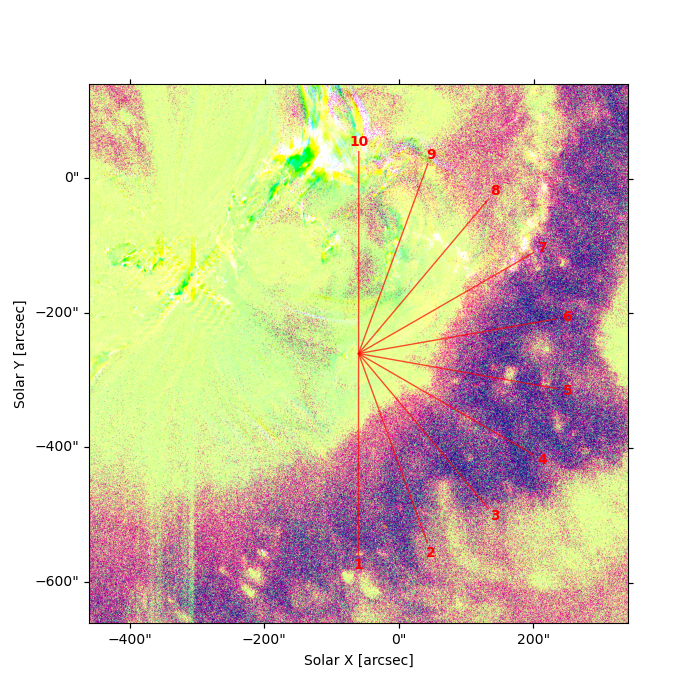

In [57]:
# Pick the sequence frame whose time is nearest REF_DATETIME.
ref_key = min(results['frames'],
              key=lambda k: abs(pd.to_datetime(k) - pd.to_datetime(REF_DATETIME)))
frame = results['frames'][ref_key]

savepath = os.path.join(FIG_DIR, f'rgb_slits_{REGION}.png') if SAVE_FIGS else None
plot_rgb_with_slits(
    frame['rgb'], frame['ref_map'], slits=results['slits'],
    title=f'AIA 211/193/171 running ratio\n{REGION} - {frame["frame_times"]["G"]}',
    show_title=SHOW_TITLES, savepath=savepath, dpi=FIG_DPI)
plt.show()

### 1c. Export the running-ratio RGB sequence as PNG stills

Writes one PNG per frame to `RGB_SEQ_DIR` (a dedicated folder), in time order, to show the eruption's evolution. Set `RGB_SEQ_OVERLAY = True` in the config to draw the slit fan on each still; pass `arc_results['slits']` instead once the great arcs are built.

In [ ]:
rgb_seq_paths = export_rgb_sequence(
    results, RGB_SEQ_DIR, region=REGION,
    overlay=results['slits'] if RGB_SEQ_OVERLAY else None,
    show_title=SHOW_TITLES, dpi=FIG_DPI)

### 3. Trace a feature on each slit

Run the cell below **once** to create the shared stores, then run the interactive
cell repeatedly: set `ACTIVE_SLIT_ID`, click out `N_REPEATS` traces, change the id,
repeat. Re-running the store cell wipes previous clicks.

**Two methods, one store.** This cell is the *manual* tracer. For Bezier tracing use §3b instead (`TRACE_MODE = 'bezier'`); either way the front lands in `clicked_traces` and the rest of the notebook is unchanged.

In [ ]:
clicked_traces = {}
jplot_times_by_slit = {}

In [ ]:
ACTIVE_SLIT_ID = 'slit_01'   # 1-based ids (slit_01 ... slit_10); re-run per slit

fig, ax, jplot, jtimes, distances = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL,
    distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP,
    show_title=SHOW_TITLES)

clicked_traces = collect_repeated_jplot_traces(
    fig, ax, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    n_repeats=N_REPEATS, storage=clicked_traces, y_unit=DISTANCE_UNIT,
    show_title=SHOW_TITLES)

jplot_times_by_slit[ACTIVE_SLIT_ID] = jtimes
plt.show()

### 3b. (option) Trace with a Bezier curve instead

Set `TRACE_MODE = 'bezier'`. Run the **placement** cell and drag the sliders until the dashed curve lies on the front (axes are in J-plot index space: x = time-frame index, y = distance-bin index; `BEZIER_N_ANCHORS` picks quadratic vs cubic). Then run the **commit** cell: it stores a jittered ensemble into `clicked_traces` for `ACTIVE_SLIT_ID` and previews the mean ± SEM. Sections 4 and 5 below then work unchanged. The same `add_bezier_trace` works for great arcs — pass `arc_results`, `clicked_traces_arc` and an `arc_*` id.

(Run the §3 init cell — `clicked_traces = {}` — once before committing, since the commit cell appends to that store.)

In [ ]:
# ---- Option B, step 1: place the Bezier curve with the sliders ---------------
from ipywidgets import FloatSlider, Layout, interact, fixed

ACTIVE_SLIT_ID = 'slit_01'   # slit to trace with the Bezier (set independently of §3)

bz_jplot, bz_times, bz_distances, _bz_dlabel = build_jplot(
    results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL, distance_unit=DISTANCE_UNIT)
bz_array = np.asarray(bz_jplot).T                 # (n_distance, n_time): index space for the Bezier
bz_n = BEZIER_N_ANCHORS + 1                        # 2 = quadratic, 3 = cubic
_nt, _nd = len(bz_times), len(bz_distances)
_L = Layout(width='700px')

bz_x_start = FloatSlider(min=0, max=_nt - 1, step=0.5, value=0.10 * _nt, description='x_start', layout=_L)
bz_y_start = FloatSlider(min=0, max=_nd - 1, step=0.5, value=0.10 * _nd, description='y_start', layout=_L)
bz_x_end   = FloatSlider(min=0, max=_nt - 1, step=0.5, value=0.90 * _nt, description='x_end', layout=_L)
bz_y_end   = FloatSlider(min=0, max=_nd - 1, step=0.5, value=0.85 * _nd, description='y_end', layout=_L)
bz_cx1     = FloatSlider(min=0, max=_nt - 1, step=0.5, value=0.50 * _nt, description='cx1', layout=_L)
bz_cy1     = FloatSlider(min=0, max=_nd - 1, step=0.5, value=0.50 * _nd, description='cy1', layout=_L)
bz_cx2     = FloatSlider(min=0, max=_nt - 1, step=0.5, value=0.65 * _nt, description='cx2', layout=_L)
bz_cy2     = FloatSlider(min=0, max=_nd - 1, step=0.5, value=0.40 * _nd, description='cy2', layout=_L)

def _bz_update(x_start, y_start, x_end, y_end, cx1, cy1, cx2, cy2):
    anchors = [[cx1, cy1]] if bz_n == 2 else [[cx1, cy1], [cx2, cy2]]
    _, xc, yc = extract_bezier_values(bz_array, x_start, y_start, x_end, y_end,
                                      anchors, bz_n, BEZIER_NUM_POINTS)
    vmin, vmax = np.nanpercentile(bz_array, (1, 99))
    fig, ax = plt.subplots(figsize=[9, 5])
    ax.pcolormesh(np.arange(_nt), np.arange(_nd), bz_array, vmin=vmin, vmax=vmax, cmap=JPLOT_CMAP)
    ax.plot(xc, yc, color='red', ls='--', lw=1.2, marker='x', ms=4)
    ax.scatter([x_start, x_end], [y_start, y_end], c=['lime', 'yellow'], ec='k', s=55, zorder=5)
    ax.scatter([a[0] for a in anchors], [a[1] for a in anchors], c='cyan', ec='k', s=45, zorder=5)
    ax.set_xlabel('Time-frame index')
    ax.set_ylabel('Distance-bin index')
    ax.set_title(f'{ACTIVE_SLIT_ID} | Bezier n={bz_n} — drag sliders onto the front')
    plt.show()

_bz_kw = dict(x_start=bz_x_start, y_start=bz_y_start, x_end=bz_x_end, y_end=bz_y_end,
              cx1=bz_cx1, cy1=bz_cy1)
if bz_n == 3:
    _bz_kw.update(cx2=bz_cx2, cy2=bz_cy2)
else:                                             # quadratic: freeze the 2nd anchor
    _bz_kw.update(cx2=fixed(bz_cx2.value), cy2=fixed(bz_cy2.value))
interact(_bz_update, **_bz_kw)


In [ ]:
# ---- Option B, step 2: commit the fitted curve (jittered ensemble) -----------
_bz_anchors = ([[bz_cx1.value, bz_cy1.value]] if bz_n == 2
               else [[bz_cx1.value, bz_cy1.value], [bz_cx2.value, bz_cy2.value]])
clicked_traces = add_bezier_trace(
    clicked_traces, ACTIVE_SLIT_ID, bz_jplot, bz_times, bz_distances,
    p_start=(bz_x_start.value, bz_y_start.value),
    p_end=(bz_x_end.value, bz_y_end.value),
    anchors=_bz_anchors, feature_id=FEATURE_ID,
    n_repeats=BEZIER_N_REPEATS, jitter=BEZIER_JITTER,
    num_points=BEZIER_NUM_POINTS, y_unit=DISTANCE_UNIT, seed=BEZIER_SEED)
jplot_times_by_slit[ACTIVE_SLIT_ID] = bz_times

# Preview: mean +/- SEM of the Bezier ensemble on the J-plot (data coordinates).
trace_summary = summarise_repeated_traces(
    clicked_traces, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID, jplot_times=bz_times)
fig, ax, *_ = plot_jplot(results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL,
                         distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM,
                         cmap=JPLOT_CMAP, show_title=SHOW_TITLES)
overplot_trace_summary(ax, trace_summary, errorbar_every=2)
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_bezier_jplot.png'), dpi=FIG_DPI)
plt.show()


### 4. Inspect the active slit (optional)

Overlay the mean trace on its J-plot and show the kinematics for whichever slit
`ACTIVE_SLIT_ID` currently points at.


In [ ]:
trace_summary = summarise_repeated_traces(
    clicked_traces, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    jplot_times=jplot_times_by_slit[ACTIVE_SLIT_ID])

fig, ax, *_ = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL,
    distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP,
    show_title=SHOW_TITLES)
overplot_trace_summary(ax, trace_summary, errorbar_every=2)
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_jplot.png'), dpi=FIG_DPI)
plt.show()

In [ ]:
kin = compute_trace_kinematics(
    trace_summary, smooth=True,
    savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)
kin_prefix = os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}') if SAVE_FIGS else None
plot_trace_kinematics(kin, errorbar_every=1, show_title=SHOW_TITLES,
                      savepath_prefix=kin_prefix, dpi=FIG_DPI)
plt.show()

# Optional per-slit trace-summary CSV:
trace_summary_to_dataframe(trace_summary).to_csv(
    os.path.join(OUTPUT_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_trace_summary.csv'), index=False)

In [ ]:
# # In case you want to redo a slit
# clicked_traces.pop('slit_06')
# jplot_times_by_slit.pop('slit_06')

### 5. Aggregate every traced slit, save, and plot

Operates on whatever slits exist in `clicked_traces`, so it scales from one slit
to the whole fan without edits.


In [ ]:
traced_slit_ids = list(clicked_traces.keys())

all_kin = compute_kinematics_for_slits(
    clicked_traces=clicked_traces,
    slit_ids=traced_slit_ids,
    feature_id=FEATURE_ID,
    jplot_times_by_slit=jplot_times_by_slit,
    smooth=True, savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)

# One CSV per slit.
for s in all_kin:
    slit_csv = os.path.join(OUTPUT_DIR, f'{s}_{FEATURE_ID}_kinematics.csv')
    kinematics_to_dataframe(all_kin[s]).to_csv(slit_csv, index=False)
    print(f'Saved {slit_csv}')

# Combined CSV (all slits stacked).
df_all_kin = pd.concat([kinematics_to_dataframe(all_kin[s]) for s in all_kin],
                       ignore_index=True)
out_csv = os.path.join(OUTPUT_DIR, f'all_slits_{FEATURE_ID}_kinematics.csv')
df_all_kin.to_csv(out_csv, index=False)
print(f'Saved {out_csv}')
df_all_kin.head()

In [ ]:
sp_speed = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_speed.png') if SAVE_FIGS else None
sp_acc   = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_acceleration.png') if SAVE_FIGS else None

plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_speed,
                     dpi=FIG_DPI, annotate_scalar=True)
plt.show()

plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_acc,
                            dpi=FIG_DPI, annotate_scalar=True)
plt.show()

Load the CSV files if saved already

In [ ]:
# Standalone reload path (fresh session): the module carries identical copies of
# the plotting helpers, so importing them here deliberately shadows the notebook ones.
from load_and_plot_kinematics import (load_all_kin, plot_all_slit_speeds,
                                      plot_all_slit_accelerations)

all_kin = load_all_kin(OUTPUT_DIR, feature_id=FEATURE_ID)
plot_all_slit_speeds(all_kin)
plot_all_slit_accelerations(all_kin)

---
## Great-arc tracing — mirror of the radial-slit pipeline

Same idea as the radial slits, but the track follows a **great circle on the Sun**
rather than a straight line in the plane of sky. The only genuinely new pieces are
the arc geometry and the per-frame sampling; everything downstream
(`plot_jplot`, `collect_repeated_jplot_traces`, `summarise_repeated_traces`,
`compute_trace_kinematics`, the aggregation helpers) is reused unchanged by
building an `arc_results` dict with the **same schema** as `results`.

Each arc stores two distance axes:

* `distance_Mm` — the **true great-circle surface distance** (inner angle × R$_\odot$),
  used for the J-plots and kinematics. This is de-projected, so speeds are the real
  along-surface speeds.
* `distance_Mm_proj` / `distance_arcsec` — the **plane-of-sky projected** distance,
  the same convention the slits use, kept so the two methods can be compared
  like-for-like.


In [ ]:
from sunpy.coordinates.utils import GreatArc

def make_arc_coords(start_xy, end_xy, map_obj, n_samples=300):
    """Great-arc path from start_xy to end_xy (arcsec) on map_obj.

    Returns a dict with the sampled sky path and two distance axes:
      tx_arcsec, ty_arcsec : plane-of-sky coords of the n_samples points
      separation_arcsec    : projected angular separation from the arc start
      surface_Mm           : true great-circle surface distance (inner angle x R_sun)
    """
    start = SkyCoord(start_xy[0] * u.arcsec, start_xy[1] * u.arcsec,
                     frame=map_obj.coordinate_frame)
    end   = SkyCoord(end_xy[0]   * u.arcsec, end_xy[1]   * u.arcsec,
                     frame=map_obj.coordinate_frame)
    arc = GreatArc(start, end, points=n_samples)
    coords = arc.coordinates()

    tx = coords.Tx.to_value(u.arcsec)
    ty = coords.Ty.to_value(u.arcsec)
    separation_arcsec = coords.separation(coords[0]).to_value(u.arcsec)

    # Inner angle from the start (rad) x physical solar radius -> surface distance [Mm].
    inner = arc.inner_angles()
    inner_rad = inner.to_value(u.rad) if hasattr(inner, 'to_value') else np.asarray(inner)
    surface_Mm = inner_rad * const.radius.to_value(u.Mm)

    return {
        'start_xy': start_xy, 'end_xy': end_xy,
        'arc': arc, 'coords': coords,
        'tx_arcsec': tx, 'ty_arcsec': ty,
        'separation_arcsec': separation_arcsec,
        'surface_Mm': surface_Mm,
    }


def make_arc_grid(start_xy, end_points, map_obj, n_samples=300):
    """Dict of great arcs sharing one origin: {'arc_NN': {...}} (1-based)."""
    arcs = {}
    for i, end_xy in enumerate(end_points):
        arc_id = f'arc_{i + 1:02d}'
        arcs[arc_id] = make_arc_coords(start_xy, end_xy, map_obj, n_samples=n_samples)
    return arcs


def sample_map_along_arc(map_obj, arc, order=1):
    """Interpolate map values along a pre-built great arc (from make_arc_coords).

    Mirrors sample_map_along_slit: rebuilds the sky path in this map's frame and
    samples with map_coordinates for a fixed-length, sub-pixel intensity profile.
    Returns (separation_arcsec, surface_Mm, intensity, coords).
    """
    coords = SkyCoord(arc['tx_arcsec'] * u.arcsec, arc['ty_arcsec'] * u.arcsec,
                      frame=map_obj.coordinate_frame)
    px, py = map_obj.world_to_pixel(coords)
    intensity = map_coordinates(
        map_obj.data.astype(float),
        [py.to_value(u.pix), px.to_value(u.pix)],
        order=order, mode='constant', cval=np.nan,
    )
    return arc['separation_arcsec'], arc['surface_Mm'], intensity, coords


def trace_arcs_for_frame(frame_result, arcs):
    """Sample every arc on every channel of one processed frame.

    Channel dicts mirror the slit traces but add 'distance_Mm' (true surface
    distance, used by build_jplot) and 'distance_Mm_proj' (projected, for
    comparison). 'distance_arcsec' stays the projected angular separation.
    """
    factor = arcsec_to_Mm_factor(frame_result['ref_map'])
    traces = {}
    for arc_id, arc in arcs.items():
        traces[arc_id] = {
            'start_xy': arc['start_xy'],
            'end_xy': arc['end_xy'],
            'channels': {},
        }
        for colour, mp in frame_result['cropped_maps'].items():
            sep_arcsec, surface_Mm, intensity, coords = sample_map_along_arc(mp, arc)
            traces[arc_id]['channels'][colour] = {
                'distance_arcsec': sep_arcsec,
                'distance_Mm': surface_Mm,
                'distance_Mm_proj': sep_arcsec * factor,
                'intensity': intensity,
                'coords': coords,
            }
    return traces


def build_arc_results(results, start_xy, end_points, n_samples=300):
    """Trace great arcs through the frames already built in `results`.

    Returns an arc_results dict with the same schema as `results`
    ({'frames','traces','slits','target_times'}), so every downstream J-plot
    and kinematics helper works on it unchanged. The arc grid is created once on
    the first frame's reference map and reused, matching the slit workflow.
    """
    times = list(results['frames'].keys())
    ref_map = results['frames'][times[0]]['ref_map']
    arcs = make_arc_grid(start_xy, end_points, ref_map, n_samples=n_samples)

    arc_traces = {}
    for t in tqdm(times, desc='Tracing arcs through frames'):
        arc_traces[t] = trace_arcs_for_frame(results['frames'][t], arcs)

    return {
        'frames': results['frames'],      # reuse the same RGB / ratio frames
        'traces': arc_traces,
        'slits': arcs,                     # 'slits' key kept for schema parity
        'target_times': results.get('target_times', times),
    }

### A1. Build the arc grid and trace it through the sequence

Reuses the frames already in `results`, so this does not rebuild any RGB maps.


In [ ]:
# Great-arc end points: one per slit angle, at the projected tip of the matching
# radial slit, so arc_NN is the great-circle counterpart of slit_NN and the two
# methods can be compared track by track. Origin shared with the slits.
ARC_END_POINTS = [
    (SLIT_START_XY[0] + SLIT_LENGTH_ARCSEC * np.cos(np.deg2rad(a)),
     SLIT_START_XY[1] + SLIT_LENGTH_ARCSEC * np.sin(np.deg2rad(a)))
    for a in SLIT_ANGLES_DEG
]

arc_results = build_arc_results(
    results, start_xy=SLIT_START_XY, end_points=ARC_END_POINTS, n_samples=N_SAMPLES)

ARC_IDS = list(arc_results['slits'].keys())
print(f'{len(ARC_IDS)} arcs: {ARC_IDS}')

### A2. Preview the arc fan on the reference frame


In [ ]:
arc_ref_key = min(arc_results['frames'],
                  key=lambda k: abs(pd.to_datetime(k) - pd.to_datetime(REF_DATETIME)))
arc_frame = arc_results['frames'][arc_ref_key]

arc_ref_map = arc_frame['ref_map']
ny, nx = arc_frame['rgb'].shape[:2]

fig = plt.figure(figsize=[7, 7])
ax = fig.add_subplot(projection=arc_ref_map)
ax.imshow(arc_frame['rgb'], origin='lower')
ax.grid(False)
for arc_id, arc in arc_results['slits'].items():
    coords = arc['coords']
    ax.plot_coord(coords, color='cyan', lw=1, alpha=0.8)
    # Label inside the submap: use the last sampled point still within the FOV
    # (stepped back a few samples so the number sits clear of the edge).
    inside = sunpy.map.contains_coordinate(arc_ref_map, coords)
    label_idx = max(np.where(inside)[0][-1] - 3, 0) if inside.any() else len(coords) - 1
    ax.text_coord(coords[label_idx], int(arc_id.split('_')[-1]), color='cyan',
                  fontsize=10, fontweight='bold', ha='center', va='center')
# Clip the view to the AIA submap so off-FOV arc segments add no white border.
ax.set_xlim(-0.5, nx - 0.5)
ax.set_ylim(-0.5, ny - 0.5)
if SHOW_TITLES:
    ax.set_title(f'AIA 211/193/171 running ratio - great arcs\n'
                 f'{REGION} - {arc_frame["frame_times"]["G"]}')
ax.set_xlabel('Solar X [arcsec]')
ax.set_ylabel('Solar Y [arcsec]')
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'rgb_arcs_{REGION}.png'), dpi=FIG_DPI)
plt.show()

### A3. Trace the feature on each arc

Same interactive workflow as the slits, with separate stores
(`clicked_traces_arc`, `jplot_times_by_arc`) so the slit traces are untouched.
Run the store cell **once**, then set `ACTIVE_ARC_ID`, click out `N_REPEATS`
traces, change the id, and repeat. The J-plot y-axis is the **true surface
distance** in Mm. Note `JPLOT_DLIM` was tuned for the slits — widen it here if
the front sits outside that window on the arcs.


In [ ]:
clicked_traces_arc = {}
jplot_times_by_arc = {}

In [ ]:
ACTIVE_ARC_ID = 'arc_01'   # arc_01 ... arc_10; re-run per arc

fig, ax, jplot, jtimes, distances = plot_jplot(
    arc_results, slit_id=ACTIVE_ARC_ID, channel=CHANNEL,
    distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP,
    show_title=SHOW_TITLES, track_name='arc')

clicked_traces_arc = collect_repeated_jplot_traces(
    fig, ax, slit_id=ACTIVE_ARC_ID, feature_id=FEATURE_ID,
    n_repeats=N_REPEATS, storage=clicked_traces_arc, y_unit=DISTANCE_UNIT,
    show_title=SHOW_TITLES)

jplot_times_by_arc[ACTIVE_ARC_ID] = jtimes
plt.show()

### A4. Aggregate every traced arc, save, and plot

`compute_kinematics_for_slits` is reused verbatim — it only needs a store, a list
of ids, and a per-id time grid. CSVs are written with an `arc_` /
`all_arcs_` prefix so they never collide with the slit outputs.


In [ ]:
traced_arc_ids = list(clicked_traces_arc.keys())

arc_kin = compute_kinematics_for_slits(
    clicked_traces=clicked_traces_arc,
    slit_ids=traced_arc_ids,
    feature_id=FEATURE_ID,
    jplot_times_by_slit=jplot_times_by_arc,
    smooth=True, savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)

for a in arc_kin:
    arc_csv = os.path.join(OUTPUT_DIR, f'{a}_{FEATURE_ID}_kinematics.csv')
    kinematics_to_dataframe(arc_kin[a]).to_csv(arc_csv, index=False)
    print(f'Saved {arc_csv}')

df_all_arc_kin = pd.concat([kinematics_to_dataframe(arc_kin[a]) for a in arc_kin],
                           ignore_index=True)
out_csv = os.path.join(OUTPUT_DIR, f'all_arcs_{FEATURE_ID}_kinematics.csv')
df_all_arc_kin.to_csv(out_csv, index=False)
print(f'Saved {out_csv}')
# df_all_arc_kin.head()
df_all_arc_kin

In [ ]:
# Per-arc overview (legend ordered by arc number, like the slit overview).
_plot_all_slits(arc_kin, 'speed', 'Speed [km/s]', 'Speed along arcs',
                show_title=SHOW_TITLES, annotate_scalar=True,
                savepath=os.path.join(FIG_DIR, f'all_arcs_{FEATURE_ID}_speed.png') if SAVE_FIGS else None,
                dpi=FIG_DPI)
plt.show()

_plot_all_slits(arc_kin, 'acceleration', r'Acceleration [m/s$^2$]', 'Acceleration along arcs',
                show_title=SHOW_TITLES, annotate_scalar=True,
                savepath=os.path.join(FIG_DIR, f'all_arcs_{FEATURE_ID}_acceleration.png') if SAVE_FIGS else None,
                dpi=FIG_DPI)
plt.show()

---
## Compare the two methods: radial slits vs great arcs

The slit speeds are **projected** (plane-of-sky), the arc speeds are
**de-projected** (true along-surface). Comparing them shows how much the
straight-slit projection biases the kinematics. Comparison is done three ways:
an overlay of all tracks per method, a per-track scalar table (time-averaged
speed and acceleration), and the method-level mean ± standard deviation.


In [ ]:
def _scalar_kinematics_table(all_kin, method):
    """Time-averaged speed & acceleration per track -> tidy DataFrame."""
    rows = []
    for tid, kin in sorted(all_kin.items(), key=lambda kv: _track_number(kv[0])):
        rows.append({
            'method': method,
            'track_id': tid,
            'track_number': _track_number(tid),
            'speed_kms': np.nanmean(kin['speed_mean']),
            'speed_sem_kms': np.nanmean(kin['speed_sem']),
            'acceleration_ms2': np.nanmean(kin['acceleration_mean']),
            'acceleration_sem_ms2': np.nanmean(kin['acceleration_sem']),
        })
    return pd.DataFrame(rows)


def compare_methods_overlay(all_kin_slits, all_kin_arcs, quantity='speed',
                            ylabel='Speed [km/s]', show_title=True,
                            savepath=None, dpi=300):
    """Overlay one kinematic quantity for the slit and arc methods on one axes."""
    fig, ax = plt.subplots(figsize=[9, 5])
    for method, group, cmap_name in [('slit', all_kin_slits, 'Blues'),
                                     ('arc',  all_kin_arcs,  'Oranges')]:
        items = sorted(group.items(), key=lambda kv: _track_number(kv[0]))
        n = max(len(items), 1)
        cmap = plt.get_cmap(cmap_name)
        for j, (tid, kin) in enumerate(items):
            x = np.asarray(kin['x_time_num'])
            ax.plot(x, kin[f'{quantity}_mean'], '-', lw=1.2,
                    color=cmap(0.35 + 0.6 * j / n), label=tid)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(f'{quantity.capitalize()}: radial slits (blue) vs great arcs (orange)')
    ax.legend(fontsize=7, ncol=2)
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax

In [ ]:
# Per-track scalar summary for each method + method-level mean/std.
tbl_slits = _scalar_kinematics_table(all_kin, 'slit')
tbl_arcs  = _scalar_kinematics_table(arc_kin, 'arc')
comparison_table = pd.concat([tbl_slits, tbl_arcs], ignore_index=True)

cmp_csv = os.path.join(OUTPUT_DIR, f'slit_vs_arc_{FEATURE_ID}_summary.csv')
comparison_table.to_csv(cmp_csv, index=False)
print(f'Saved {cmp_csv}')

method_summary = (comparison_table
                  .groupby('method')[['speed_kms', 'acceleration_ms2']]
                  .agg(['mean', 'std', 'count']))
print(method_summary)
comparison_table

In [ ]:
compare_methods_overlay(
    all_kin, arc_kin, quantity='speed', ylabel='Speed [km/s]', show_title=SHOW_TITLES,
    savepath=os.path.join(FIG_DIR, f'compare_speed_{FEATURE_ID}.png') if SAVE_FIGS else None,
    dpi=FIG_DPI)
plt.show()

compare_methods_overlay(
    all_kin, arc_kin, quantity='acceleration', ylabel=r'Acceleration [m/s$^2$]',
    show_title=SHOW_TITLES,
    savepath=os.path.join(FIG_DIR, f'compare_accel_{FEATURE_ID}.png') if SAVE_FIGS else None,
    dpi=FIG_DPI)
plt.show()

In [ ]:
# Time-averaged front speed per track, slits vs arcs.
fig, ax = plt.subplots(figsize=[9,5])
for method, tbl, colour in [('slit', tbl_slits, 'tab:blue'),
                            ('arc',  tbl_arcs,  'tab:orange')]:
    ax.errorbar(tbl['track_number'], tbl['speed_kms'], yerr=tbl['speed_sem_kms'],
                fmt='o-', capsize=3, color=colour, label=method)
all_tracks = sorted(set(tbl_slits['track_number']).union(tbl_arcs['track_number']))
ax.set_xticks(all_tracks)                       # integer track numbers only
ax.set_xlabel('Track number')
ax.set_ylabel('Time-averaged speed [km/s]')
if SHOW_TITLES:
    ax.set_title('Mean front speed per track: radial slits vs great arcs')
ax.legend()
fig.tight_layout()
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'compare_speed_per_track_{FEATURE_ID}.png'), dpi=FIG_DPI)
plt.show()

In [ ]:
# Quantitative comparison: distribution of per-track time-averaged kinematics.
fig, axes = plt.subplots(1, 2, figsize=[10, 5])
for ax, col, ylabel in [(axes[0], 'speed_kms', 'Time-averaged speed [km/s]'),
                        (axes[1], 'acceleration_ms2', r'Time-averaged acceleration [m/s$^2$]')]:
    data = [tbl_slits[col].to_numpy(), tbl_arcs[col].to_numpy()]
    bp = ax.boxplot(data, showmeans=True, widths=0.5, patch_artist=True)
    for patch, colour in zip(bp['boxes'], ['tab:blue', 'tab:orange']):
        patch.set_facecolor(colour)
        patch.set_alpha(0.4)
    # Overlay the individual tracks (jittered) for transparency on small samples.
    rng = np.random.default_rng(0)
    for j, vals in enumerate(data, start=1):
        ax.scatter(np.full(len(vals), j) + rng.uniform(-0.06, 0.06, len(vals)),
                   vals, color='black', s=18, zorder=3)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['radial slits', 'great arcs'])
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', alpha=0.3)
if SHOW_TITLES:
    fig.suptitle('Per-track kinematics distribution: radial slits vs great arcs')
fig.tight_layout()
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'compare_boxplot_{FEATURE_ID}.png'), dpi=FIG_DPI)
plt.show()